### Final Project Overview
Analyzing the Impact of Recession on Automobile Sales

You have been hired by XYZAutomotives as a data scientist. Your first task is to analyze the historical data and give the company directors insights on how the sales were affected during times of recession. You will provide a number of charts/plots to visualize the data and make it easy for the directors to understand your analysis. 

Part 1: Create visualizations using Matplotib, Seaborn & Folium
Objective:

The objective of this part of the Final Assignment is to analyze the historical trends in automobile sales during recession periods. The goal is to provide insights into how the sales of XYZAutomotives, a company specializing in automotive sales, were affected during times of recession.

In this lab you will create visualizations using Matplotlib, Seaborn, Pandas.
Tasks to be performed

TASK 1.1: Develop a Line chart using the functionality of pandas to show how automobile sales fluctuate from year to year.

TASK 1.2: How do trends in advertising expenditure correlate with automobile sales during non-recession periods, and what insights can be derived from this relationship.

TASK 1.3: Use the functionality of Seaborn Library to create a visualization to compare the sales trend per vehicle type for a recession period with a non-recession period.

TASK 1.4: Use sub plotting to compare the variations in GDP during recession and non-recession period by developing line plots for each period.

TASK 1.5: Develop a Bubble plot for displaying the impact of seasonality on Automobile Sales.

TASK 1.6: Use the functionality of Matplotlib to develop a scatter plot to identify the correlation between average vehicle price relate to the sales volume during recessions.

TASK 1.7: Create a pie chart to display the portion of advertising expenditure of XYZAutomotives during recession and non-recession periods.

TASK 1.8: Develop a pie chart to display the total Advertisement expenditure for each vehicle type during recession period.

TASK 1.9: Develop a line plot to analyse the effect of the unemployment rate on vehicle type and sales during the Recession Period.
Part 2: Create Dashboard using Plotly and Dash
Objective:

The objective of this part of the Fnal assignment is to create dashboards to contain your plots and charts and to provide the directors with the ability to select a particular report or a period of time so they can discuss the data in detail.

In this lab you will create dashboards using Dash and Plotly and then add user-interactions to your dashboards.
Creating dashboards and adding customizations to the dashboards

The directors of XYZAutomobiles have requested a dashboard to be developed so they can drill into the data in more detail for specific years or by different categories. Your second task is to create a suitable dashboard and add in user interactions so that the directors can select the data they want to review without the need to request new plots.
Tasks to be performed

TASK 2.1: Create a Dash application and give it a meaningful title.

TASK 2.2: Add drop-down menus to your dashboard with appropriate titles and options.

TASK 2.3: Add a division for output display with appropriate id and classname property.

TASK 2.4: Creating Callbacks; Define the callback function to update the input container based on the selected statistics and the output container.

TASK 2.5: Create and display graphs for Recession Report Statistics.

In [1]:
# Initialisation

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import folium 

In [2]:
# Importing data

df = pd.read_csv('https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/d51iMGfp_t0QpO30Lym-dw/automobile-sales.csv')

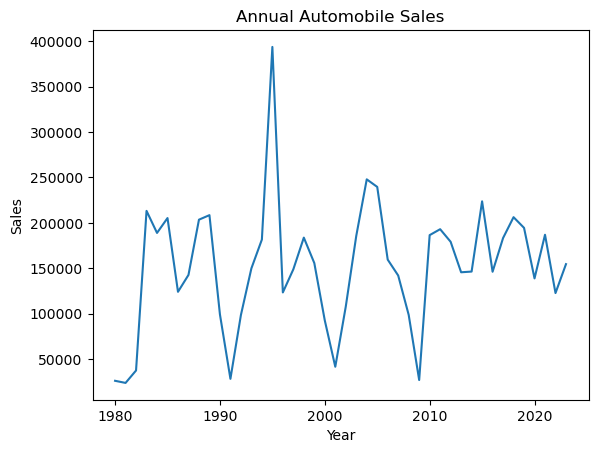

In [3]:
# TASK 1.1: Develop a Line chart using the functionality of pandas to show how automobile sales fluctuate from year to year.

df11 = df.groupby('Year')['Automobile_Sales'].sum()

# Plot

df11.plot(kind = 'line')
plt.title('Annual Automobile Sales')
plt.ylabel('Sales')
plt.show()

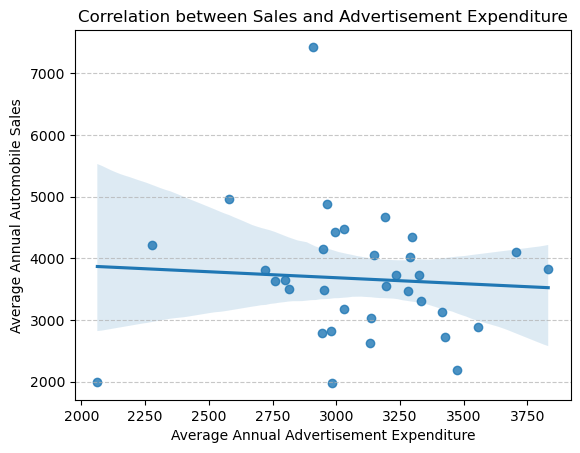

In [4]:
# TASK 1.2: How do trends in advertising expenditure correlate with automobile sales during non-recession periods, and what insights can be derived from this relationship.
# Relationship shows a slightly negative correlations with large confidence intervals.
df_temp = df[df['Recession'] == 0]
df12 = df_temp.groupby('Year').agg(Avg_Sales = ('Automobile_Sales', 'mean'), Avg_Ad_Spend = ('Advertising_Expenditure', 'mean'))
sns.regplot(data = df12, x = 'Avg_Ad_Spend', y = 'Avg_Sales')

plt.xlabel('Average Annual Advertisement Expenditure')
plt.ylabel('Average Annual Automobile Sales')
plt.title('Correlation between Sales and Advertisement Expenditure')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

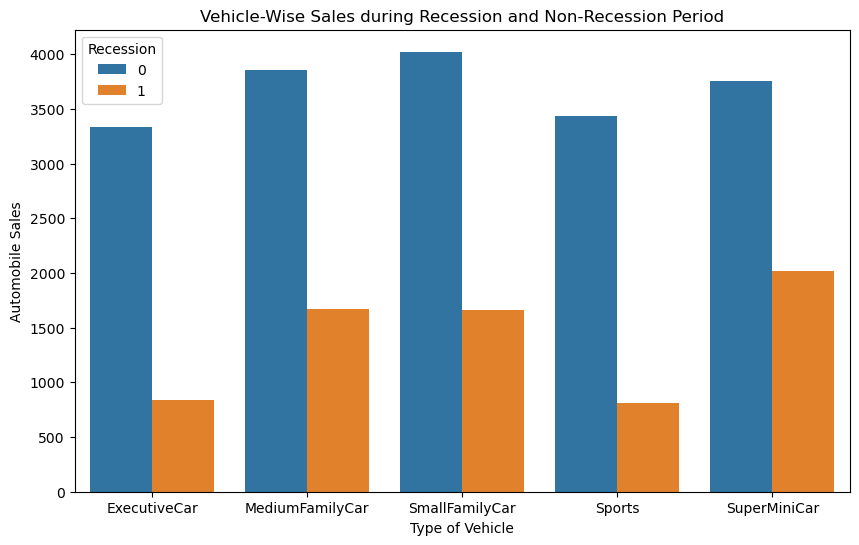

In [5]:
# TASK 1.3: Use the functionality of Seaborn Library to create a visualization to compare the sales trend per vehicle type for a recession period with a non-recession period
# During recession people by way less cars.
df13 = df.groupby(['Vehicle_Type', 'Recession'])['Automobile_Sales'].mean().to_frame()
df13 = df13.reset_index()

# Plot

plt.figure(figsize = (10, 6))

sns.barplot(data = df13, x = 'Vehicle_Type', y = 'Automobile_Sales', hue = 'Recession')
plt.xlabel('Type of Vehicle')
plt.ylabel('Automobile Sales')
plt.title('Vehicle-Wise Sales during Recession and Non-Recession Period')

plt.show()

Text(0, 0.5, 'GDP')

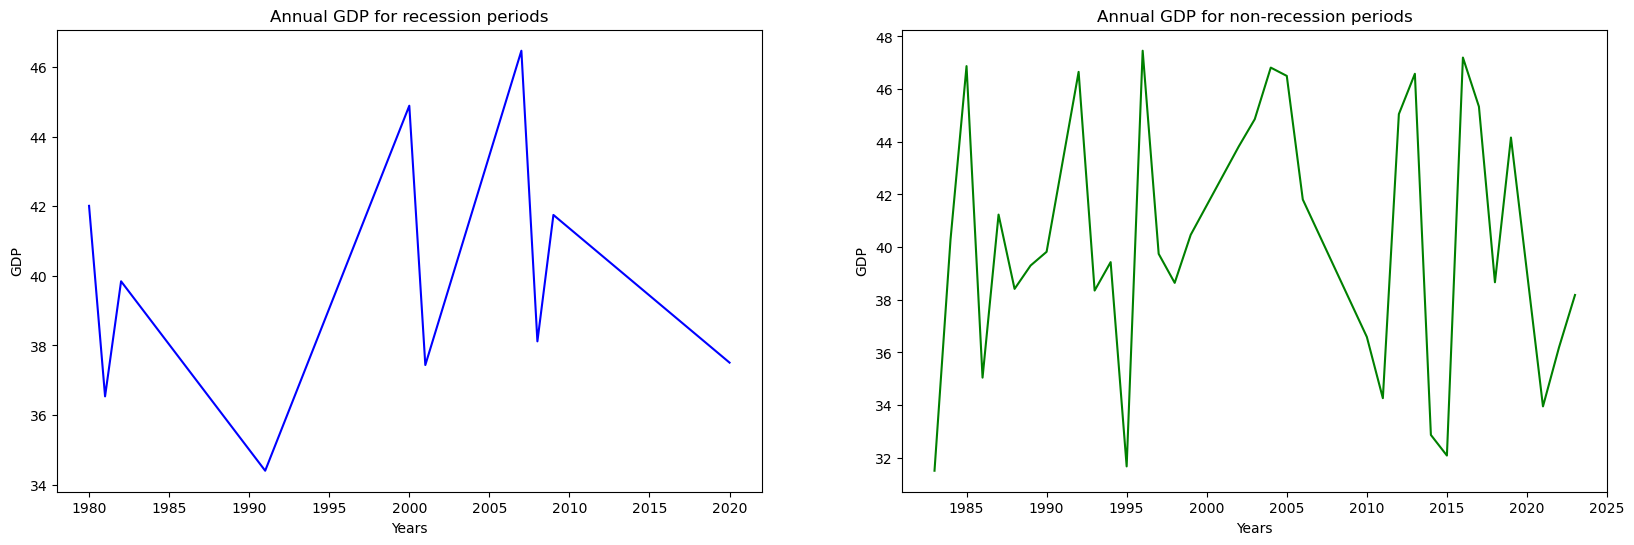

In [6]:
# TASK 1.4: Use sub plotting to compare the variations in GDP during recession and non-recession period by developing line plots for each period.

df_14r = df[df['Recession'] == 1].groupby('Year')['GDP'].mean()
df_14nr = df[df['Recession'] == 0].groupby('Year')['GDP'].mean()

# Plot

fig = plt.figure()

ax0 = fig.add_subplot(1, 2, 1) 
ax1 = fig.add_subplot(1, 2, 2) 

# Subplot 1: Line plot
df_14r.plot(kind='line', color='blue', figsize=(20, 6), ax=ax0) # add to subplot 1
ax0.set_title('Annual GDP for recession periods')
ax0.set_xlabel('Years')
ax0.set_ylabel('GDP')

# Subplot 2: Line plot
df_14nr.plot(kind='line', color = 'green', figsize=(20, 6), ax=ax1) # add to subplot 2
ax1.set_title('Annual GDP for non-recession periods')
ax1.set_xlabel('Years')
ax1.set_ylabel('GDP')

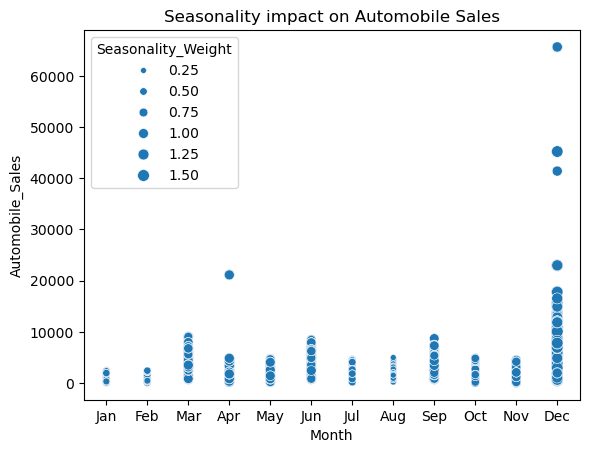

In [7]:
# TASK 1.5: Develop a Bubble plot for displaying the impact of seasonality on Automobile Sales.

size = df['Seasonality_Weight']

sns.scatterplot(data= df, x='Month', y='Automobile_Sales', size=size)

plt.xlabel('Month')
plt.ylabel('Automobile_Sales')
plt.title('Seasonality impact on Automobile Sales')

plt.show()

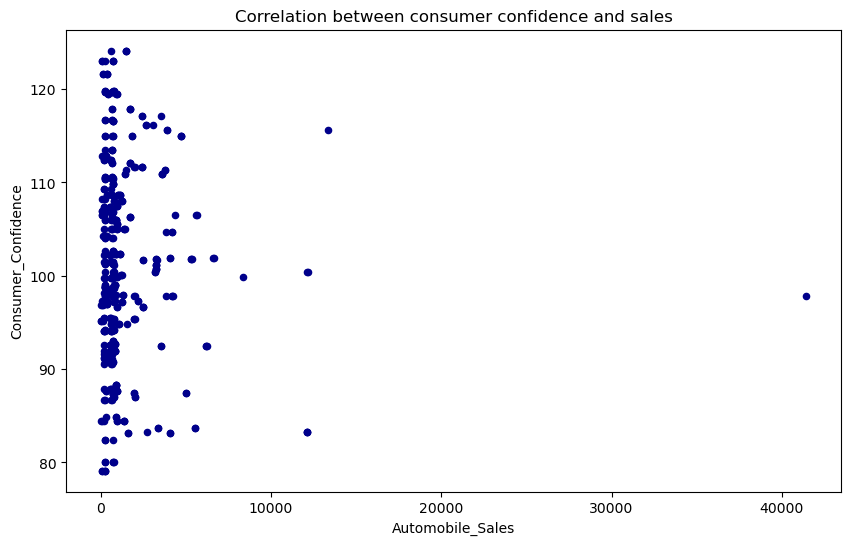

In [8]:
# TASK 1.6: Use the functionality of Matplotlib to develop a scatter plot to identify the correlation between average vehicle price relate to the sales volume during recessions.

df16 = df[df['Recession'] == 1]

df16.plot(kind='scatter', x='Automobile_Sales', y='Consumer_Confidence', figsize=(10, 6), color='darkblue')
plt.title('Correlation between consumer confidence and sales')
plt.show()

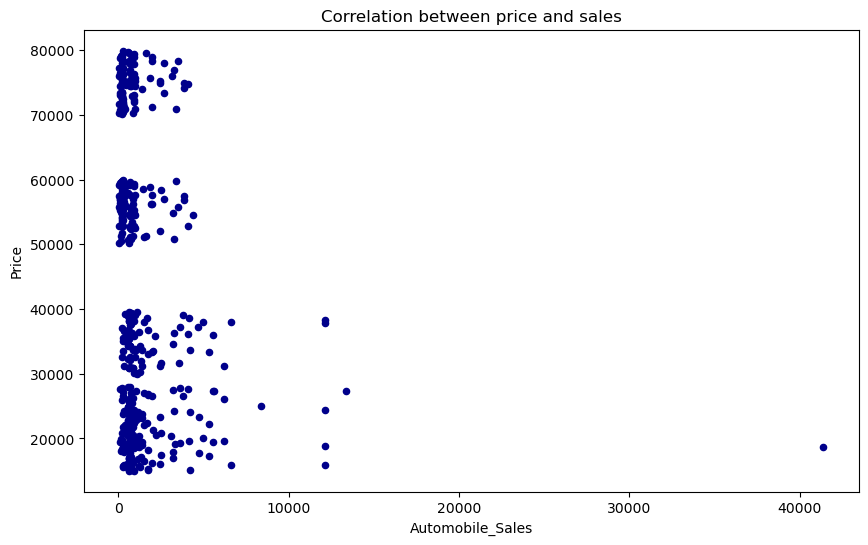

In [9]:
df16.plot(kind='scatter', x='Automobile_Sales', y='Price', figsize=(10, 6), color='darkblue')
plt.title('Correlation between price and sales')
plt.show()

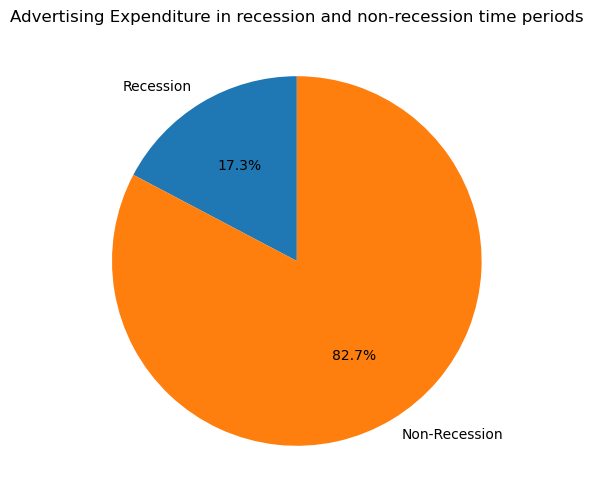

In [10]:
# TASK 1.7: Create a pie chart to display the portion of advertising expenditure of XYZAutomotives during recession and non-recession periods.

# Filter the data 
Rdata = df[df['Recession'] == 1]
NRdata = df[df['Recession'] == 0]

# Calculate the total advertising expenditure for both periods
RAtotal = Rdata['Advertising_Expenditure'].sum()
NRAtotal = NRdata['Advertising_Expenditure'].sum()

# Create a pie chart for the advertising expenditure 
plt.figure(figsize=(8, 6))

labels = ['Recession', 'Non-Recession']
sizes = [RAtotal, NRAtotal]
plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90)

plt.title('Advertising Expenditure in recession and non-recession time periods')

plt.show()


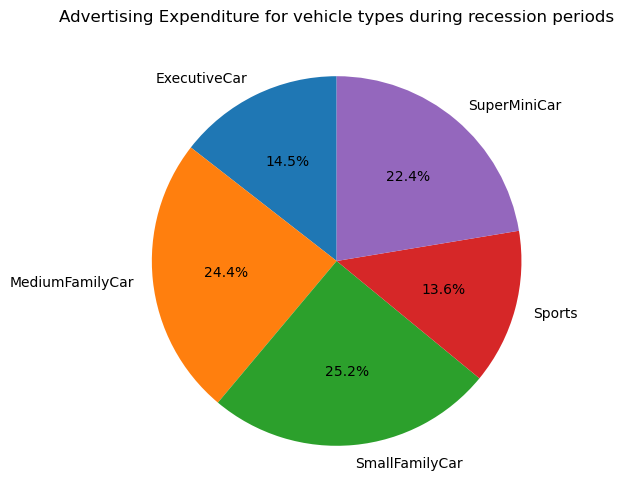

In [11]:
# TASK 1.8: Develop a pie chart to display the total Advertisement expenditure for each vehicle type during recession period.

df18 = df[df["Recession"] == 1]

df18 = df18.groupby('Vehicle_Type')['Advertising_Expenditure'].sum()
df18 = df18.reset_index()
df18_tot = df18['Advertising_Expenditure'].sum()

plt.figure(figsize=(8, 6))

plt.pie(df18['Advertising_Expenditure'], labels = df18['Vehicle_Type'], autopct='%1.1f%%', startangle=90)

plt.title('Advertising Expenditure for vehicle types during recession periods')

plt.show()


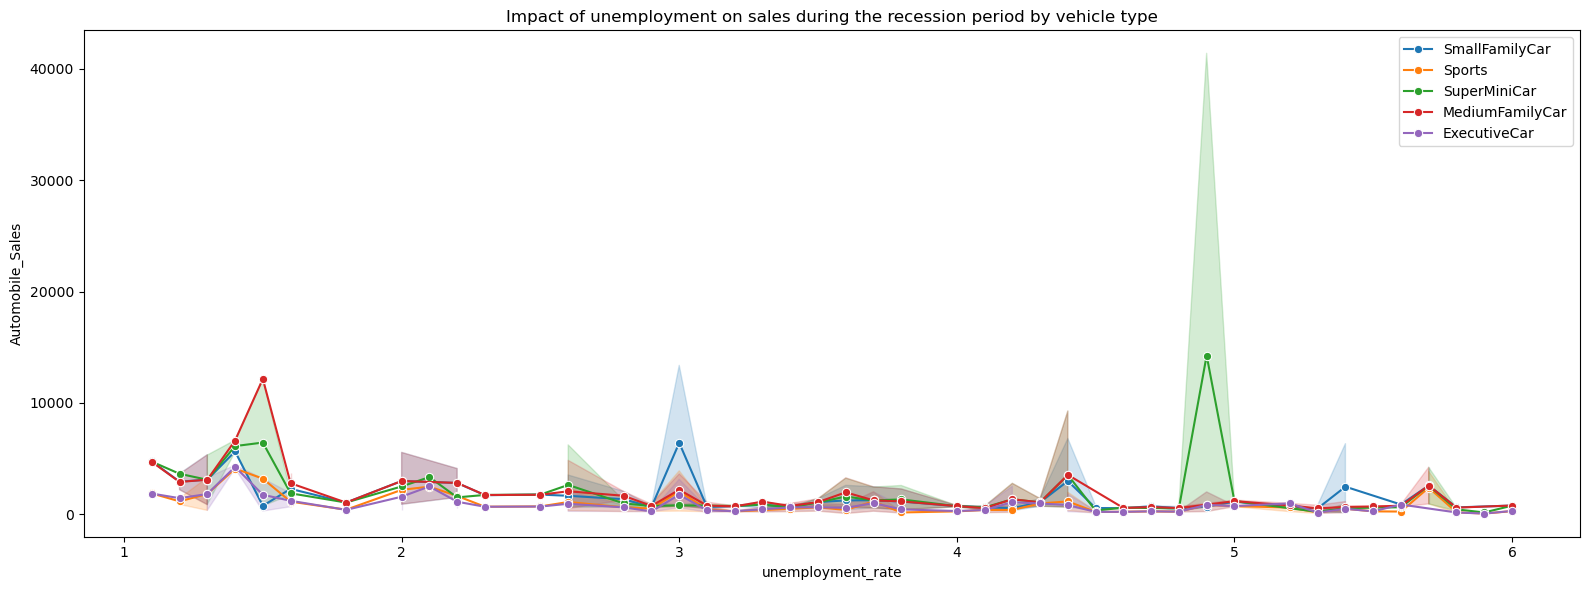

In [12]:
# TASK 1.9: Develop a line plot to analyse the effect of the unemployment rate on vehicle type and sales during the Recession Period.

df_rec = df[df['Recession'] == 1]

# Set figure size
plt.figure(figsize=(16, 6))

# Create line plot showing effect of unemployment rate on automobile sales, by vehicle type
sns.lineplot(
    data=df_rec,
    x='unemployment_rate',               # Replace with unemployment rate column (e.g., 'unemployment_rate')
    y='Automobile_Sales',               # Replace with automobile sales column (e.g., 'Automobile_Sales')
    hue='Vehicle_Type',             # Replace with vehicle type column (e.g., 'Vehicle_Type')
    marker='o'
)

# Customize labels, legend, and title
plt.title('Impact of unemployment on sales during the recession period by vehicle type')
plt.legend()

# Show plot
plt.tight_layout()
plt.show()